<a href="https://colab.research.google.com/github/irenehavsa/mental-disorder-prevalence/blob/main/notebooks/02_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Project: Analysis of the Depression Trend Over Time in Indonesia
# Notebook: 02_eda.ipynb
# Author: Irene Havsa

In [ ]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Forecast

### 1. Load Data

The dataset used in this notebook is sourced from Kaggle. See the notebook `00_fetch_and_preprocess` for more details.

In [ ]:
# Read the CSV
url = "https://raw.githubusercontent.com/irenehavsa/mental-disorder-prevalence/main/data/processed/mental_disorders_prevalence_yearly.csv"
df = pd.read_csv(url)
display(df.head())

,entity,code,year,mental_disorder,prevalence
0,Brunei,BRN,1990.0,schizophrenia,0.274544
1,Brunei,BRN,1991.0,schizophrenia,0.273819
2,Brunei,BRN,1992.0,schizophrenia,0.273212
3,Brunei,BRN,1993.0,schizophrenia,0.272736
4,Brunei,BRN,1994.0,schizophrenia,0.272383


In [ ]:
# Include only depression prevalence data for Indonesia
df = df[(df['mental_disorder'] == 'depression') & (df['entity'] == 'Indonesia')]
display(df)

,entity,code,year,mental_disorder,prevalence
1676,Indonesia,IDN,1990.0,depression,2.632151
1677,Indonesia,IDN,1991.0,depression,2.626713
1678,Indonesia,IDN,1992.0,depression,2.622194
1679,Indonesia,IDN,1993.0,depression,2.618790
1680,Indonesia,IDN,1994.0,depression,2.616341
1681,Indonesia,IDN,1995.0,depression,2.615768
1682,Indonesia,IDN,1996.0,depression,2.616892
1683,Indonesia,IDN,1997.0,depression,2.618268
1684,Indonesia,IDN,1998.0,depression,2.619794
1685,Indonesia,IDN,1999.0,depression,2.621846


###2. Forecast with Linear Regression

In [ ]:
# Create training data
X = df['year'].values.reshape(-1, 1)
y = df['prevalence']

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the predicted prevalance
y_pred = model.predict(X)
df['prevalence_pred'] = y_pred

df.head()

,entity,code,year,mental_disorder,prevalence,prevalence_pred
1676,Indonesia,IDN,1990.0,depression,2.632151,2.622189
1677,Indonesia,IDN,1991.0,depression,2.626713,2.622254
1678,Indonesia,IDN,1992.0,depression,2.622194,2.622318
1679,Indonesia,IDN,1993.0,depression,2.618790,2.622382
1680,Indonesia,IDN,1994.0,depression,2.616341,2.622447


In [ ]:
df_melted = pd.melt(df, id_vars=['entity', 'code', 'year', 'mental_disorder'], var_name='target_type', value_name='value')
df_melted.head()

,entity,code,year,mental_disorder,target_type,value
0,Indonesia,IDN,1990.0,depression,prevalence,2.632151
1,Indonesia,IDN,1991.0,depression,prevalence,2.626713
2,Indonesia,IDN,1992.0,depression,prevalence,2.622194
3,Indonesia,IDN,1993.0,depression,prevalence,2.618790
4,Indonesia,IDN,1994.0,depression,prevalence,2.616341


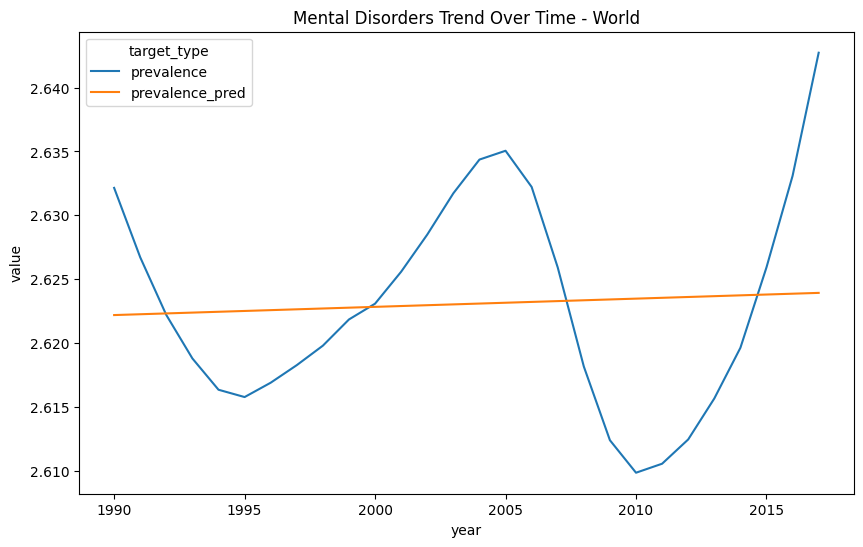

In [ ]:
# df_for_visual = df_melted

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='year', y='value', hue='target_type')
plt.title('Depression Prevalance')
plt.show()

As we can see on the image above, the high volatility of the prevalence value makes linear regression not a good approach for forcasting. Besides, the data point is very small, only 28 points. For the sake of presenting forecasting method, addming more granularity synthetically is one of the options for the next step.